<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/first_test_all_news_03_10_23.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/snapcrack/all-the-news?select=articles3.csv
all-new

In [86]:
# import libraries
import pandas as pd
import re

import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
# nltk imports
from nltk.tokenize import word_tokenize  # tokenize the text == the text is splitted into words in list
from nltk.corpus import stopwords  # this contain common stop words that has no effect in analysis
from nltk.stem import WordNetLemmatizer  # Lemmatization is the process of grouping together the different inflected forms of a word so they can be analyzed as a single item

# download nltk corpus (first time only)
import nltk

nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package basque_grammars to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package basque_grammars is already up-to-date!
[nltk_data]    | Downloading package bcp47 to /root/nltk_data...
[nltk_data]    |   Package bcp47 is already up-to-dat

True

In [87]:
df1 = pd.read_csv('articles1.csv')
df1

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
0,0,17283,House Republicans Fret About Winning Their Hea...,New York Times,Carl Hulse,2016-12-31,2016.0,12.0,NaN,WASHINGTON — Congressional Republicans have...
1,1,17284,Rift Between Officers and Residents as Killing...,New York Times,Benjamin Mueller and Al Baker,2017-06-19,2017.0,6.0,NaN,"After the bullet shells get counted, the blood..."
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri..."
3,3,17286,"Among Deaths in 2016, a Heavy Toll in Pop Musi...",New York Times,William McDonald,2017-04-10,2017.0,4.0,NaN,"Death may be the great equalizer, but it isn’t..."
4,4,17287,Kim Jong-un Says North Korea Is Preparing to T...,New York Times,Choe Sang-Hun,2017-01-02,2017.0,1.0,NaN,"SEOUL, South Korea — North Korea’s leader, ..."
...,...,...,...,...,...,...,...,...,...,...
49995,53287,73465,"Rex Tillerson Says Climate Change Is Real, but …",Atlantic,Robinson Meyer,2017-01-11,2017.0,1.0,NaN,"As chairman and CEO of ExxonMobil, Rex Tillers..."
49996,53288,73466,The Biggest Intelligence Questions Raised by t...,Atlantic,Amy Zegart,2017-01-11,2017.0,1.0,NaN,I’ve spent nearly 20 years looking at intellig...
49997,53289,73467,Trump Announces Plan That Does Little to Resol...,Atlantic,Jeremy Venook,2017-01-11,2017.0,1.0,NaN,Donald Trump will not be taking necessary st...
49998,53290,73468,Dozens of For-Profit Colleges Could Soon Close,Atlantic,Emily DeRuy,2017-01-11,2017.0,1.0,NaN,Dozens of colleges could be forced to close ...


In [88]:
df2 = pd.read_csv('articles2.csv')
df2

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
0,53293,73471,Patriots Day Is Best When It Digs Past the Her...,Atlantic,David Sims,2017-01-11,2017.0,1.0,NaN,"Patriots Day, Peter Berg’s new thriller that r..."
1,53294,73472,A Break in the Search for the Origin of Comple...,Atlantic,Ed Yong,2017-01-11,2017.0,1.0,NaN,"In Norse mythology, humans and our world were ..."
2,53295,73474,Obama’s Ingenious Mention of Atticus Finch,Atlantic,Spencer Kornhaber,2017-01-11,2017.0,1.0,NaN,“If our democracy is to work in this increasin...
3,53296,73475,"Donald Trump Meets, and Assails, the Press",Atlantic,David A. Graham,2017-01-11,2017.0,1.0,NaN,Updated on January 11 at 5:05 p. m. In his fir...
4,53297,73476,Trump: ’I Think’ Hacking Was Russian,Atlantic,Kaveh Waddell,2017-01-11,2017.0,1.0,NaN,Updated at 12:25 p. m. After months of equivoc...
...,...,...,...,...,...,...,...,...,...,...
49994,103453,151902,"If Baltimore is serious about police reform, g...",Guardian,Lawrence Grandpre,2016-08-12,2016.0,8.0,https://www.theguardian.com/commentisfree/2016...,There have been many proposed solutions to the...
49995,103454,151903,The transition from summer to fall feels like ...,Guardian,Mary Valle,2016-08-28,2016.0,8.0,https://www.theguardian.com/commentisfree/2016...,"Maybe I feel like August won’t let go of me, b..."
49996,103455,151904,"Colombia: Farc’s female fighters, then and now...",Guardian,NaN,2016-09-16,2016.0,9.0,https://www.theguardian.com/artanddesign/2016/...,"Diana Marcela, 28, has spent 13 years with Far..."
49997,103456,151905,Why I’m optimistic about 2017,Guardian,Paul Mason,2016-12-26,2016.0,12.0,https://www.theguardian.com/politics/commentis...,"This Christmas break, for anybody steeped in t..."


In [89]:
df3 = pd.read_csv('articles3.csv')
df3

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
0,103459,151908,Alton Sterling’s son: ’Everyone needs to prote...,Guardian,Jessica Glenza,2016-07-13,2016.0,7.0,https://www.theguardian.com/us-news/2016/jul/1...,The son of a Louisiana man whose father was sh...
1,103460,151909,Shakespeare’s first four folios sell at auctio...,Guardian,NaN,2016-05-25,2016.0,5.0,https://www.theguardian.com/culture/2016/may/2...,Copies of William Shakespeare’s first four boo...
2,103461,151910,My grandmother’s death saved me from a life of...,Guardian,Robert Pendry,2016-10-31,2016.0,10.0,https://www.theguardian.com/commentisfree/2016...,"Debt: $20, 000, Source: College, credit cards,..."
3,103462,151911,I feared my life lacked meaning. Cancer pushed...,Guardian,Bradford Frost,2016-11-26,2016.0,11.0,https://www.theguardian.com/commentisfree/2016...,"It was late. I was drunk, nearing my 35th birt..."
4,103463,151912,Texas man serving life sentence innocent of do...,Guardian,NaN,2016-08-20,2016.0,8.0,https://www.theguardian.com/us-news/2016/aug/2...,A central Texas man serving a life sentence fo...
...,...,...,...,...,...,...,...,...,...,...
42566,146028,218078,An eavesdropping Uber driver saved his 16-year...,Washington Post,Avi Selk,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,Uber driver Keith Avila picked up a p...
42567,146029,218079,Plane carrying six people returning from a Cav...,Washington Post,Sarah Larimer,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,Crews on Friday continued to search L...
42568,146030,218080,After helping a fraction of homeowners expecte...,Washington Post,Renae Merle,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,When the Obama administration announced a...
42569,146031,218081,"Yes, this is real: Michigan just banned bannin...",Washington Post,Chelsea Harvey,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,This story has been updated. A new law in...


In [90]:
words = ['GHG emission','esg','climate','emission','emissions','net zero','global warming','greenhouse gas','greenhouse',
         'paris agreement','greenwashing', 'Climate change', 'Renewable energy', 'Air quality', 'pollution',
         'Waste management', 'Clean water', 'Clean Energy', 'Sustainable Cities', 'sustainable','sustainabilitty',
         'Responsible Consumption','environmental', 'Climate Action', 'ESG', 'environment']

In [91]:
df_1 = df1

In [92]:
df_1['c'] = df_1.content.str.findall('({0})'.format('|'.join(words)), flags=re.IGNORECASE)
df_1['d'] = df_1['c'].str.len()

In [93]:
df_1 = df_1[df_1.d != 0]

In [94]:
df_1

,Unnamed: 0,id,title,publication,author,date,year,month,url,content,c,d
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri...",[climate],1
7,7,17290,"After ‘The Biggest Loser,’ Their Bodies Fought...",New York Times,Gina Kolata,2017-02-08,2017.0,2.0,NaN,"Danny Cahill stood, slightly dazed, in a blizz...",[environment],1
10,10,17293,Weak Federal Powers Could Limit Trump’s Climat...,New York Times,Justin Gillis,2017-01-03,2017.0,1.0,NaN,With Donald J. Trump about to take control of ...,"[renewable energy, global warming, climate, re...",23
11,11,17294,Can Carbon Capture Technology Prosper Under Tr...,New York Times,John Schwartz,2017-01-05,2017.0,1.0,NaN,"THOMPSONS, Tex. — Can one of the most promi...","[global warming, climate, environmental, emiss...",16
12,12,17295,"Mar-a-Lago, the Future Winter White House and ...",New York Times,Maggie Haberman,2017-01-02,2017.0,1.0,NaN,"WEST PALM BEACH, Fla. — When Donald J. Tr...","[environment, environment]",2
...,...,...,...,...,...,...,...,...,...,...,...,...
49983,53275,73453,‘We Have a Problem’: John Kerry on Making Poli...,Atlantic,Uri Friedman,2017-01-10,2017.0,1.0,NaN,In one of his last public appearances as U. S....,"[environment, climate]",2
49984,53276,73454,The Enduring Mystery of Pain Measurement,Atlantic,John Walsh,2017-01-10,2017.0,1.0,NaN,"One night in May, my wife sat up in bed and sa...","[environment, environment]",2
49989,53281,73459,The Atlantic Daily: Passing the Presidential Mic,Atlantic,Rosa Inocencio Smith,2017-01-11,2017.0,1.0,NaN,This article is part of a feature we a...,[climate],1
49995,53287,73465,"Rex Tillerson Says Climate Change Is Real, but …",Atlantic,Robinson Meyer,2017-01-11,2017.0,1.0,NaN,"As chairman and CEO of ExxonMobil, Rex Tillers...","[climate, Paris Agreement, climate, global war...",25


In [95]:
df_2 = df2
df_2['c'] = df_2.content.str.findall('({0})'.format('|'.join(words)), flags=re.IGNORECASE)
df_2['d'] = df_2['c'].str.len()

In [96]:
df_2 = df_2[df_2.d != 0]

In [97]:
df_2

,Unnamed: 0,id,title,publication,author,date,year,month,url,content,c,d
1,53294,73472,A Break in the Search for the Origin of Comple...,Atlantic,Ed Yong,2017-01-11,2017.0,1.0,NaN,"In Norse mythology, humans and our world were ...","[environmental, environment]",2
7,53300,73479,The Trump Administration’s Conflicts of Intere...,Atlantic,Jeremy Venook,2017-01-11,2017.0,1.0,NaN,"With confirmation hearings beginning, attentio...",[climate],1
8,53301,73484,The Longstanding Crisis Facing Tribal Schools,Atlantic,Alia Wong,2017-01-12,2017.0,1.0,NaN,"Havasu Canyon is home to turquoise waterfalls,...",[environment],1
9,53302,73485,The Atlantic Daily: Loose Ends and Legacy,Atlantic,Rosa Inocencio Smith,2017-01-12,2017.0,1.0,NaN,This article is part of a feature we a...,"[climate, climate]",2
13,53306,73489,A Sanctions Skeptic for State?,Atlantic,Siddhartha Mahanta,2017-01-12,2017.0,1.0,NaN,"Rex Tillerson, Donald Trump’s choice to serve ...",[climate],1
...,...,...,...,...,...,...,...,...,...,...,...,...
49976,103435,151878,"The cool girls, good girls and bad girls of mo...",Guardian,Judy Berman,2016-05-28,2016.0,5.0,https://www.theguardian.com/books/booksblog/20...,“Lacey had a theory that people have a finite ...,"[climate, environment]",2
49986,103445,151890,Quarter of inmates could have been spared pris...,Guardian,Jamiles Lartey,2016-12-11,2016.0,12.0,https://www.theguardian.com/us-news/2016/dec/1...,"A quarter of the US prison population, about 3...",[environment],1
49987,103446,151895,Shepard Fairey makes Idiocracy-inspired electi...,Guardian,Erika Milvy,2016-10-07,2016.0,10.0,https://www.theguardian.com/artanddesign/2016/...,If you’ve seen the hashtags #IdiocracyToday an...,[environment],1
49988,103447,151896,France set to vote for rightwing presidential ...,Guardian,Angelique Chrisafis,2016-11-18,2016.0,11.0,https://www.theguardian.com/world/2016/nov/18/...,France votes this weekend to choose the rightw...,[climate],1


In [98]:
df_3 = df3
df_3['c'] = df_3.content.str.findall('({0})'.format('|'.join(words)), flags=re.IGNORECASE)
df_3['d'] = df_3['c'].str.len()

In [99]:
df_3 = df_3[df_3.d != 0]

In [100]:
df_3

,Unnamed: 0,id,title,publication,author,date,year,month,url,content,c,d
3,103462,151911,I feared my life lacked meaning. Cancer pushed...,Guardian,Bradford Frost,2016-11-26,2016.0,11.0,https://www.theguardian.com/commentisfree/2016...,"It was late. I was drunk, nearing my 35th birt...",[emission],1
13,103472,151923,Push for ban on domestic ivory trade spurs feu...,Guardian,Oliver Milman,2016-09-10,2016.0,9.0,https://www.theguardian.com/environment/2016/s...,A resolution to end the domestic trade in ivor...,"[environmental, sustainable, pollution, global...",5
20,103479,151932,Babies breastfed within an hour of birth are l...,Guardian,France Bégin,2016-08-05,2016.0,8.0,https://www.theguardian.com/commentisfree/2016...,What happens in an hour can make all the diffe...,"[environment, clean water]",2
25,103484,151937,Elon Musk’s self-driving evangelism masks risk...,Guardian,Sam Levin,2016-07-02,2016.0,7.0,https://www.theguardian.com/technology/2016/ju...,Elon Musk’s rockets usually do not stray beyon...,"[environment, environmental]",2
27,103486,151939,Is our world a simulation? Why some scientists...,Guardian,Olivia Solon,2016-10-11,2016.0,10.0,https://www.theguardian.com/technology/2016/oc...,When Elon Musk isn’t outlining plans to use hi...,[environment],1
...,...,...,...,...,...,...,...,...,...,...,...,...
42539,146001,218046,2016 in Washington Post editorials,Washington Post,Post Opinions Staff,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,"2016 was a bumpy year, and The Post’s editoria...","[climate, emission, Environmental, climate]",4
42543,146005,218050,Democrats’ new leader suggests John Kerry just...,Washington Post,Aaron Blake,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,There is an old saying in politics: The m...,"[environmental, environment]",2
42561,146023,218073,What U.S. Muslims fear from Trump,Washington Post,Naureen Shah,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,Naureen Shah is director of security and hu...,[climate],1
42564,146026,218076,China’s vow to shut down its ivory trade by th...,Washington Post,Simon Denyer,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,BEIJING — China promised Friday to halt ...,"[environmental, environmental]",2


In [101]:
frames = [df_1, df_2, df_3]

dataset = pd.concat(frames)

In [102]:
dataset

,Unnamed: 0,id,title,publication,author,date,year,month,url,content,c,d
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri...",[climate],1
7,7,17290,"After ‘The Biggest Loser,’ Their Bodies Fought...",New York Times,Gina Kolata,2017-02-08,2017.0,2.0,NaN,"Danny Cahill stood, slightly dazed, in a blizz...",[environment],1
10,10,17293,Weak Federal Powers Could Limit Trump’s Climat...,New York Times,Justin Gillis,2017-01-03,2017.0,1.0,NaN,With Donald J. Trump about to take control of ...,"[renewable energy, global warming, climate, re...",23
11,11,17294,Can Carbon Capture Technology Prosper Under Tr...,New York Times,John Schwartz,2017-01-05,2017.0,1.0,NaN,"THOMPSONS, Tex. — Can one of the most promi...","[global warming, climate, environmental, emiss...",16
12,12,17295,"Mar-a-Lago, the Future Winter White House and ...",New York Times,Maggie Haberman,2017-01-02,2017.0,1.0,NaN,"WEST PALM BEACH, Fla. — When Donald J. Tr...","[environment, environment]",2
...,...,...,...,...,...,...,...,...,...,...,...,...
42539,146001,218046,2016 in Washington Post editorials,Washington Post,Post Opinions Staff,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,"2016 was a bumpy year, and The Post’s editoria...","[climate, emission, Environmental, climate]",4
42543,146005,218050,Democrats’ new leader suggests John Kerry just...,Washington Post,Aaron Blake,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,There is an old saying in politics: The m...,"[environmental, environment]",2
42561,146023,218073,What U.S. Muslims fear from Trump,Washington Post,Naureen Shah,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,Naureen Shah is director of security and hu...,[climate],1
42564,146026,218076,China’s vow to shut down its ivory trade by th...,Washington Post,Simon Denyer,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,BEIJING — China promised Friday to halt ...,"[environmental, environmental]",2


In [103]:
dataset = dataset.drop(columns=['c', 'd'])

In [104]:
dataset

,Unnamed: 0,id,title,publication,author,date,year,month,url,content
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri..."
7,7,17290,"After ‘The Biggest Loser,’ Their Bodies Fought...",New York Times,Gina Kolata,2017-02-08,2017.0,2.0,NaN,"Danny Cahill stood, slightly dazed, in a blizz..."
10,10,17293,Weak Federal Powers Could Limit Trump’s Climat...,New York Times,Justin Gillis,2017-01-03,2017.0,1.0,NaN,With Donald J. Trump about to take control of ...
11,11,17294,Can Carbon Capture Technology Prosper Under Tr...,New York Times,John Schwartz,2017-01-05,2017.0,1.0,NaN,"THOMPSONS, Tex. — Can one of the most promi..."
12,12,17295,"Mar-a-Lago, the Future Winter White House and ...",New York Times,Maggie Haberman,2017-01-02,2017.0,1.0,NaN,"WEST PALM BEACH, Fla. — When Donald J. Tr..."
...,...,...,...,...,...,...,...,...,...,...
42539,146001,218046,2016 in Washington Post editorials,Washington Post,Post Opinions Staff,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,"2016 was a bumpy year, and The Post’s editoria..."
42543,146005,218050,Democrats’ new leader suggests John Kerry just...,Washington Post,Aaron Blake,2016-12-29,2016.0,12.0,https://web.archive.org/web/20161230000842/htt...,There is an old saying in politics: The m...
42561,146023,218073,What U.S. Muslims fear from Trump,Washington Post,Naureen Shah,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,Naureen Shah is director of security and hu...
42564,146026,218076,China’s vow to shut down its ivory trade by th...,Washington Post,Simon Denyer,2016-12-30,2016.0,12.0,https://web.archive.org/web/20161231004909/htt...,BEIJING — China promised Friday to halt ...


In [105]:
 dj = ['Salesforce','Procter & Gamble','Dow Inc', 'Amgen', '3M', 'IBM', 'Merck', 'American Express', 'McDonald''s',
    'Boeing', 'Coca-Cola', 'Caterpillar', 'JPMorgan Chase', 'Walt Disney', 'Johnson & Johnson', 'Walmart'
    'Home Depot', 'Intel', 'Microsoft', 'Honeywell', 'Verizon', 'Chevron', 'Cisco Systems', 'Travelers Cos.', 'UnitedHealth Group'
    'Goldman Sachs', 'Nike', 'Visa', 'Apple', 'Walgreens Boots Alliance']


In [106]:
df_4 = dataset
df_4['e'] = df_4.content.str.findall('({0})'.format('|'.join(dj)), flags=re.IGNORECASE)
df_4['f'] = df_4['e'].str.len()

In [107]:
df_4 = df_4[df_4.f != 0]

In [108]:
df_4

,Unnamed: 0,id,title,publication,author,date,year,month,url,content,e,f
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"When Walt Disney’s “Bambi” opened in 1942, cri...","[Walt Disney, Walt Disney, Walt Disney]",3
29,29,17317,The Afghan War and the Evolution of Obama - Th...,New York Times,Mark Landler,2017-01-17,2017.0,1.0,NaN,WASHINGTON — President Obama’s advisers wre...,[intel],1
51,51,17342,Tech Giants Seem Invincible. That Worries Lawm...,New York Times,Farhad Manjoo,2017-01-05,2017.0,1.0,NaN,"In the technology industry, the sharks have ne...","[IBM, Apple, Microsoft, Apple, Apple, Microsof...",11
71,71,17366,Cyberwar for Sale - The New York Times,New York Times,Mattathias Schwartz,2017-01-22,2017.0,1.0,NaN,"On the morning of May 18, 2014, Violeta Lagune...","[intel, intel, intel, intel, Microsoft, intel,...",11
113,113,17414,Trump Nominees’ Filings Threaten to Overwhelm ...,New York Times,Eric Lipton and Steve Eder,2017-01-07,2017.0,1.0,NaN,WASHINGTON — Rex W. Tillerson owns more tha...,[Walt Disney],1
...,...,...,...,...,...,...,...,...,...,...,...,...
42373,145835,217822,Tech giants pledge to keep children out of cob...,Washington Post,Peter Whoriskey,2016-12-20,2016.0,12.0,https://web.archive.org/web/20161221001859/htt...,Separate groups of the world’s leading ...,"[Apple, Apple, Apple, Apple, Apple]",5
42377,145839,217831,North Carolina lawmakers leave ‘bathroom bill’...,Washington Post,Mark Berman,2016-12-21,2016.0,12.0,https://web.archive.org/web/20161222013856/htt...,North Carolina lawmakers failed Wednesday...,[Apple],1
42389,145851,217843,"The most memorable stories of the year, as tol...",Washington Post,Washington Post Staff,2016-12-21,2016.0,12.0,https://web.archive.org/web/20161222013856/htt...,The Washington Post has 17 foreign bureau...,"[caterpillar, caterpillar]",2
42466,145928,217947,Your future commute: Flying through tubes at 7...,Washington Post,Vivek Wadhwa,2016-12-20,2016.0,12.0,https://web.archive.org/web/20161226000056/htt...,Picture the commute of the future: You li...,[visa],1


In [109]:
df_4.iloc[1540][9]

'    and   mark traditional American divides. But one fault line is not so    —   that of the contemporary hard progressive movement versus traditional politics, values, and customs. \tThe entire menu of race, class, and gender identity politics,    foreign policy, political correctness, and radical environmentalism so far have not won over most Americans. \tWhat the Benghazi scandal, the Bowe Bergdahl swap, and the Iran Deal all had in common was their reliance on ruse. If the White House and its allies had told the whole truth about all these incidents, Americans probably would have widely rejected the ideological premises that framed them. \tIn the case of Benghazi, most Americans would not fault an obscure video for causing scripted rioting and death at an American consulate and CIA annex. They would hardly believe that a policy of maintaining deliberately thin security at U. S. facilities would encourage reciprocal local good will in the Middle East. They would not agree that hold

In [110]:
test1 = df_4

In [112]:
# create preprocess_text function
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())

    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]

    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]

    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# apply the function df
test1['content'] = test1['content'].apply(preprocess_text)
test1


<ipython-input-112-a604479a9720>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test1['content'] = test1['content'].apply(preprocess_text)


,Unnamed: 0,id,title,publication,author,date,year,month,url,content,e,f
2,2,17285,"Tyrus Wong, ‘Bambi’ Artist Thwarted by Racial ...",New York Times,Margalit Fox,2017-01-06,2017.0,1.0,NaN,"walt disney ’ “ bambi ” opened 1942 , critic p...","[Walt Disney, Walt Disney, Walt Disney]",3
29,29,17317,The Afghan War and the Evolution of Obama - Th...,New York Times,Mark Landler,2017-01-17,2017.0,1.0,NaN,washington — president obama ’ adviser wrestle...,[intel],1
51,51,17342,Tech Giants Seem Invincible. That Worries Lawm...,New York Times,Farhad Manjoo,2017-01-05,2017.0,1.0,NaN,"technology industry , shark never long safe mi...","[IBM, Apple, Microsoft, Apple, Apple, Microsof...",11
71,71,17366,Cyberwar for Sale - The New York Times,New York Times,Mattathias Schwartz,2017-01-22,2017.0,1.0,NaN,"morning may 18 , 2014 , violeta lagune perplex...","[intel, intel, intel, intel, Microsoft, intel,...",11
113,113,17414,Trump Nominees’ Filings Threaten to Overwhelm ...,New York Times,Eric Lipton and Steve Eder,2017-01-07,2017.0,1.0,NaN,washington — rex w. tillerson owns $ 50 millio...,[Walt Disney],1
...,...,...,...,...,...,...,...,...,...,...,...,...
42373,145835,217822,Tech giants pledge to keep children out of cob...,Washington Post,Peter Whoriskey,2016-12-20,2016.0,12.0,https://web.archive.org/web/20161221001859/htt...,separate group world ’ leading technology comp...,"[Apple, Apple, Apple, Apple, Apple]",5
42377,145839,217831,North Carolina lawmakers leave ‘bathroom bill’...,Washington Post,Mark Berman,2016-12-21,2016.0,12.0,https://web.archive.org/web/20161222013856/htt...,north carolina lawmaker failed wednesday repea...,[Apple],1
42389,145851,217843,"The most memorable stories of the year, as tol...",Washington Post,Washington Post Staff,2016-12-21,2016.0,12.0,https://web.archive.org/web/20161222013856/htt...,washington post 17 foreign bureau staffed corr...,"[caterpillar, caterpillar]",2
42466,145928,217947,Your future commute: Flying through tubes at 7...,Washington Post,Vivek Wadhwa,2016-12-20,2016.0,12.0,https://web.archive.org/web/20161226000056/htt...,"picture commute future : live palo alto , cali...",[visa],1


In [113]:
test1.iloc[1540][9]

'mark traditional american divide . one fault line — contemporary hard progressive movement versus traditional politics , value , custom . entire menu race , class , gender identity politics , foreign policy , political correctness , radical environmentalism far american . benghazi scandal , bowe bergdahl swap , iran deal common reliance ruse . white house ally told whole truth incident , american probably would widely rejected ideological premise framed . case benghazi , american would fault obscure video causing scripted rioting death american consulate cia annex . would hardly believe policy maintaining deliberately thin security u. s. facility would encourage reciprocal local good middle east . would agree holding back american rescue force wise move likely forestall international confrontation escalation . ditto bowe bergdahl caper , american deserter afghan front . aside useful publicity “ bringing home ” american hostage , implicit progressive subtext earlier flight eventual ret

In [114]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

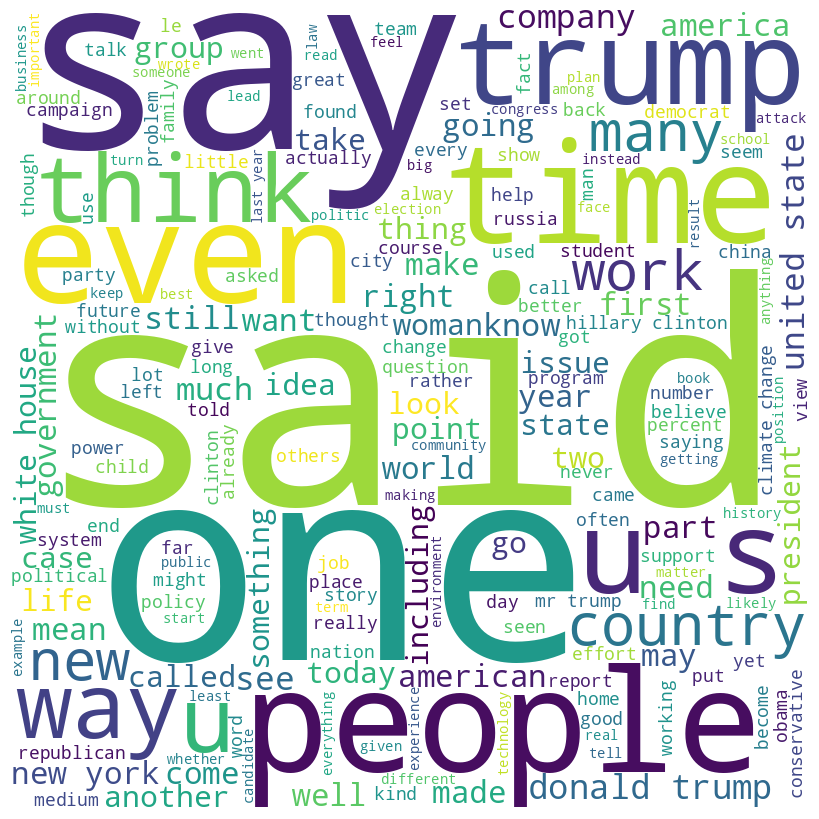

In [115]:
comment_words = ''
stopwords = set(STOPWORDS)

# iterate through the csv file
for val in test1.content:

    # typecaste each val to string
    val = str(val)

    # split the value
    tokens = val.split()

    # Converts each token into lowercase
    for i in range(len(tokens)):
        tokens[i] = tokens[i].lower()

    comment_words += " ".join(tokens)+" "

wordcloud = WordCloud(width = 800, height = 800,
                background_color ='white',
                stopwords = stopwords,
                min_font_size = 10).generate(comment_words)

# plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)

plt.show()